In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import seaborn as sns

In [2]:
np.random.seed(42)
n = 365
t = np.arange(n)
dates = pd.date_range(start='2023-01-01', periods=n, freq='D')

# trend + seasonal combined
trend_component = 0.5 * t
weekly_seasonal = 10 * np.sin(2 * np.pi * t / 7)
yearly_seasonal = 20 * np.sin(2 * np.pi * t / 365)
noise = np.random.normal(0, 3, n)
series = trend_component + weekly_seasonal + yearly_seasonal + noise

ts = pd.Series(series, index=dates, name='value')

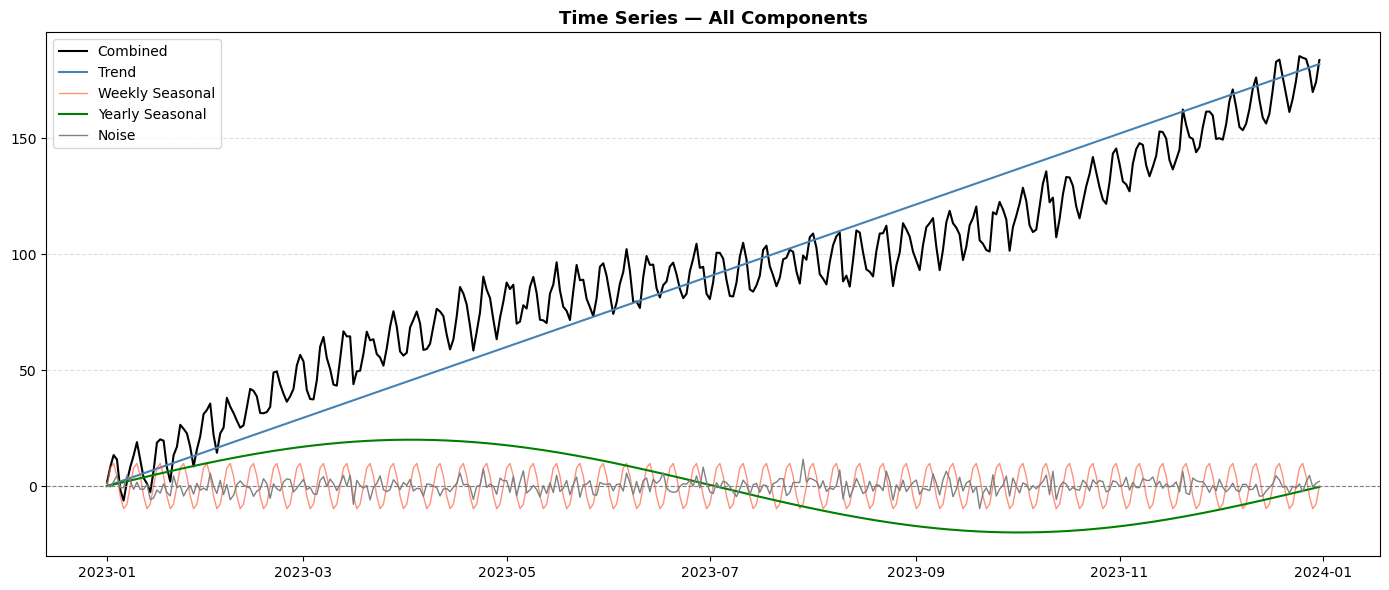

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates, series,          color='black',      lw=1.5, label='Combined')
ax.plot(dates, trend_component, color='steelblue',  lw=1.5, label='Trend')
ax.plot(dates, weekly_seasonal, color='tomato', lw=1,   label='Weekly Seasonal', alpha=0.7)
ax.plot(dates, yearly_seasonal, color='green',      lw=1.5, label='Yearly Seasonal')
ax.plot(dates, noise,           color='gray',       lw=1,   label='Noise')

ax.axhline(0, color='gray', lw=0.8, linestyle='--')
ax.legend(fontsize=10)
ax.set_title('Time Series — All Components', fontsize=13, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [4]:
def punch_holes_mcar(series, missing_rate=0.2):
    """
    MCAR — random indices, no pattern
    """
    s = series.copy().astype(float)
    n = len(s)
    missing_idx = np.random.choice(n, round(n * missing_rate), replace=False)
    s.iloc[missing_idx] = np.nan
    return s, missing_idx


def punch_holes_mar(series, missing_rate=0.2):
    """
    MAR — missingness depends on time position (observed)
    later in the year → higher chance of missing
    simulates end-of-year reporting gaps
    """
    s = series.copy().astype(float)
    n = len(s)
    
    # probability increases linearly from 5% to 35% over the year
    t_norm = np.linspace(0, 1, n)
    probs  = 0.05 + 0.30 * t_norm
    # the above probs array will be having higher probabilities at the end -> more number of values missing at the end

    n_missing  = round(n * missing_rate)
    probs_norm = probs / probs.sum()    # normalise to sum to 1 for np.random.choice
    
    missing_idx = np.random.choice(n, size=n_missing, replace=False, p=probs_norm)
    s.iloc[missing_idx] = np.nan
    return s, missing_idx


def punch_holes_mnar(series, missing_rate=0.2):
    """
    MNAR — high values are less likely to be reported
    simulates sensor saturation or deliberate suppression of peaks
    """
    s = series.copy().astype(float)
    
    # normalize series to get per-value missing probability
    # s_norm will and in turn the prob will be more for the higher s value
    s_norm = (s - s.min()) / (s.max() - s.min())
    probs  = 0.05 + 0.35 * s_norm    

    n_missing  = round(n * missing_rate)
    probs_norm = probs / probs.sum()    # normalise to sum to 1 for np.random.choice
    
    missing_idx = np.random.choice(n, size=n_missing, replace=False, p=probs_norm)
    s.iloc[missing_idx] = np.nan
    return s, missing_idx    

# the number of missing indexes in the below function will not be 20 percent always. because some of the blocks may overlap
def punch_holes_block(series, missing_rate=0.2, block_size=7):
    s = series.copy().astype(float)
    n = len(s)
    
    n_missing = round(n * missing_rate)
    n_blocks  = n_missing // block_size     # how many full blocks fit
    
    block_starts = np.random.choice(n - block_size, n_blocks, replace=False)
    missing_idx  = []
    
    for start in block_starts:
        block = list(range(start, start + block_size))
        s.iloc[block] = np.nan
        missing_idx.extend(block)
    return s, np.array(missing_idx)
    
missing_variants = {
    'MCAR':  punch_holes_mcar,
    'MAR':   punch_holes_mar,
    'MNAR':  punch_holes_mnar,
    'Block': punch_holes_block,
}

# Build a dict: ts_missing['MCAR'] = (series_with_nan, missing_idx)
ts_missing = {}
for mech_name, fn in missing_variants.items():
    s_missing, idx = fn(ts)
    ts_missing[mech_name] = (s_missing, idx)

# Quick summary
for mech_name, (s, idx) in ts_missing.items():
    print(f"  {mech_name:6s} → {s.isna().sum():3d} points missing ({s.isna().mean():.0%})")

  MCAR   →  73 points missing (20%)
  MAR    →  73 points missing (20%)
  MNAR   →  73 points missing (20%)
  Block  →  52 points missing (14%)


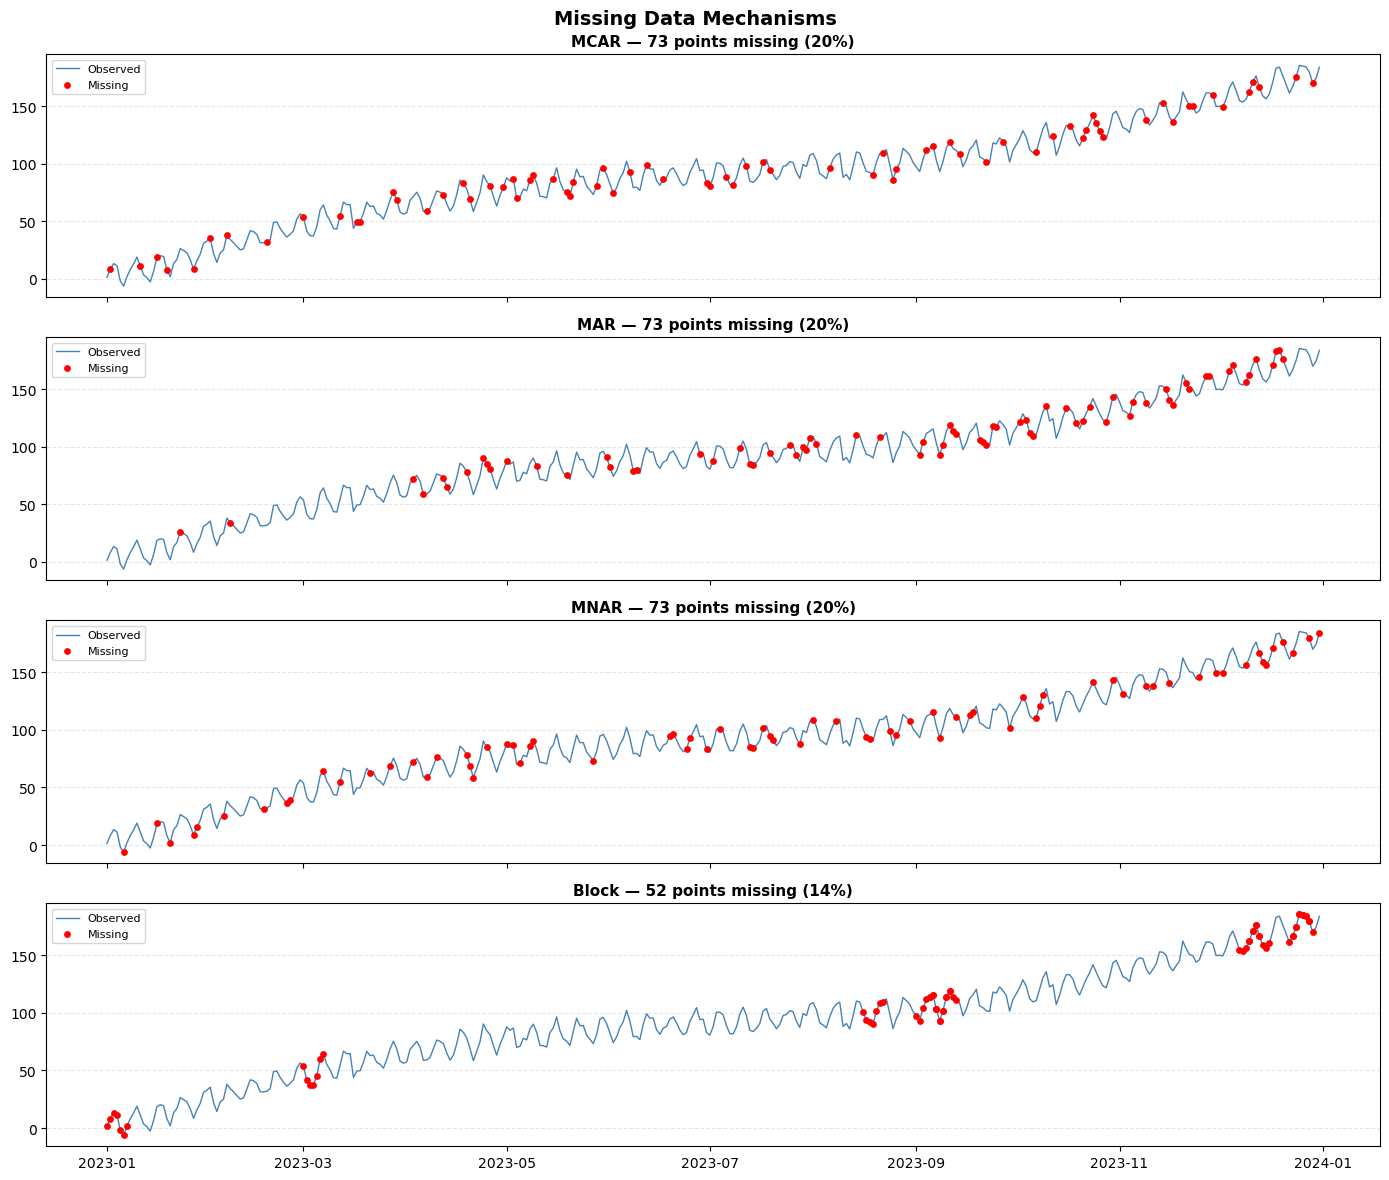

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, (mech_name, (s_missing, missing_idx)) in zip(axes, ts_missing.items()):
    
    # full true series
    ax.plot(ts.index, ts.values, color='steelblue', lw=1, label='Observed')
    
    # red dots at missing positions
    ax.scatter(ts.index[missing_idx], ts.iloc[missing_idx],
               color='red', s=15, zorder=3, label='Missing')
    
    ax.set_title(f"{mech_name} — {s_missing.isna().sum()} points missing ({s_missing.isna().mean():.0%})",
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Missing Data Mechanisms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
def impute_ffill(s):
    return s.ffill()

def impute_bfill(s):
    return s.bfill()

def impute_linear(s):
    return s.interpolate(method='linear')

def impute_spline(s, order=3):
    return s.interpolate(method='spline', order=order)

def impute_rolling_mean(s, window=7):
    # fill NaN with rolling mean of surrounding window
    filled = s.copy()
    rolling = s.rolling(window=window, min_periods=1, center=True).mean()
    filled = filled.fillna(rolling)
    return filled

imputers = {
    'ffill':        impute_ffill,
    'bfill':        impute_bfill,
    'Linear':       impute_linear,
    'Spline':       impute_spline,
    'Rolling Mean': impute_rolling_mean,
}

In [22]:
def evaluate_ts_imputations(true_series, missing_series, missing_idx):
    """
    Runs all imputers and scores on the hidden positions only.
    Returns results df + dict of imputed series.
    """
    y_true     = true_series.iloc[missing_idx]
    results    = []
    imputed    = {}

    for name, fn in imputers.items():
        s_imputed = fn(missing_series.copy())

        # if any NaN remain (e.g. ffill on leading NaNs) fill with mean
        # else it throws error in the mean_squared_error function
        s_imputed = s_imputed.fillna(s_imputed.mean())

        y_pred = s_imputed.iloc[missing_idx]
        rmse   = np.sqrt(mean_squared_error(y_true, y_pred))

        results.append({'Method': name, 'RMSE': rmse})
        imputed[name] = s_imputed

    results_df = pd.DataFrame(results)
    return results_df, imputed

In [23]:
all_results = {}

for mech_name, (s_missing, missing_idx) in ts_missing.items():
    results_df, imputed = evaluate_ts_imputations(ts, s_missing, missing_idx)
    all_results[mech_name] = {
        'results':  results_df,
        'imputed':  imputed,
        'missing':  s_missing,
        'missing_idx': missing_idx
    }

In [31]:
def full_summary_table(all_results):
    rows = []
    for mech_name in missing_variants:
        df = all_results[mech_name]['results'].set_index('Method')
        df.columns = [f'{mech_name}']
        rows.append(pd.concat([df], axis=1))
    full = pd.concat(rows, axis=1).round(4)

    styled = (
        full.style
        .highlight_min(axis=0, color='lightgreen')   # best per column
        .highlight_max(axis=0, color='#ffcccc')      # worst per column
        .set_table_styles([{
            'selector': 'caption',
            'props': [('font-size', '14px'), ('font-weight', 'bold'),
                      ('text-align', 'center'), ('padding', '8px')]
        }])
    )
    display(styled)

In [32]:
full_summary_table(all_results)

,MCAR,MAR,MNAR,Block
Method,,,,
ffill,12.542500,13.244200,9.536000,11.964100
bfill,9.280600,9.067800,16.182600,10.172300
Linear,10.450500,10.701500,7.363300,10.361800
Spline,10.707300,12.189500,51.547200,19.495700
Rolling Mean,9.774000,13.944600,10.763000,32.993700


In [33]:
"""
30% missingness
"""
ts_missing = {}
for mech_name, fn in missing_variants.items():
    s_missing, idx = fn(ts, missing_rate=0.3)   # ← change here, applies to all
    ts_missing[mech_name] = (s_missing, idx)

all_results_30perc_missing = {}

for mech_name, (s_missing, missing_idx) in ts_missing.items():
    results_df, imputed = evaluate_ts_imputations(ts, s_missing, missing_idx)
    all_results_30perc_missing[mech_name] = {
        'results':  results_df,
        'imputed':  imputed,
        'missing':  s_missing,
        'missing_idx': missing_idx
    }

full_summary_table(all_results_30perc_missing)

,MCAR,MAR,MNAR,Block
Method,,,,
ffill,9.222300,9.399100,9.267600,12.981900
bfill,11.830800,9.040800,8.965700,9.669100
Linear,6.082000,6.808500,5.798300,10.358800
Spline,10.795000,5.549500,6.033800,15.729000
Rolling Mean,9.419000,9.586200,8.307300,23.100200


In [42]:
"""
40% missingness
"""
ts_missing = {}
for mech_name, fn in missing_variants.items():
    s_missing, idx = fn(ts, missing_rate=0.4)  
    ts_missing[mech_name] = (s_missing, idx)

all_results_40perc_missing = {}

for mech_name, (s_missing, missing_idx) in ts_missing.items():
    results_df, imputed = evaluate_ts_imputations(ts, s_missing, missing_idx)
    all_results_40perc_missing[mech_name] = {
        'results':  results_df,
        'imputed':  imputed,
        'missing':  s_missing,
        'missing_idx': missing_idx
    }

full_summary_table(all_results_40perc_missing)

,MCAR,MAR,MNAR,Block
Method,,,,
ffill,9.371400,8.854800,10.298700,10.019800
bfill,17.207700,11.220800,12.385400,10.266400
Linear,6.719600,7.804700,7.764600,9.669500
Spline,24.270200,8.738000,8.945700,21.483200
Rolling Mean,12.012600,9.850000,9.754600,29.175400
